In [1]:
from data import *
from models import *
from utils import *
import torch
import random

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_path = "/home/cao/workspace/PKPD/LSQI-Challenge-2025/data/EstData.csv"
file_path = "pkpd.pkl"
model_save_path = "./model_save_best.pt"
# model_save_path = None

# train experiments

In [3]:
prepare_dataframe(data_path, file_path)
data_loader_1d_3m = eICUDataLoader(batch_size=512, file_path=file_path, 
                             t_headings=['t'],
                             x_headings=['x'],
                             cond_headings=['c_dose', 'c_bw', 'c_comed'],
                             memory=3)

train_loader_1d_3m = data_loader_1d_3m.get_train_loader(shuffle=True)
val_loader_1d_3m = data_loader_1d_3m.get_val_loader()

True
True
True
True
True


Epoch 500/10000, Loss: 0.11321964301168919


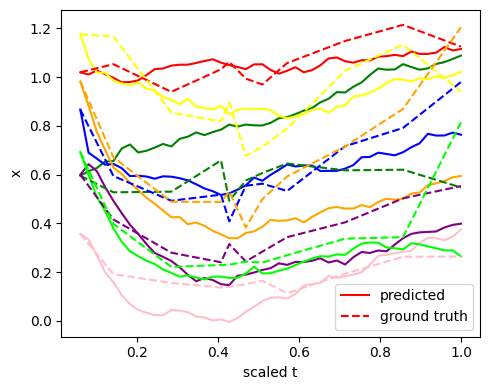

validation loss: 0.02734828181564808
Epoch 1000/10000, Loss: 0.11092584766447544


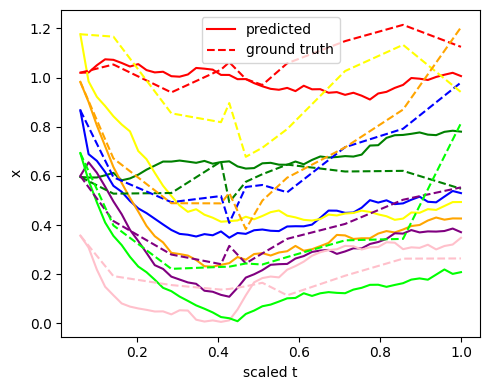

validation loss: 0.061841461807489395
Epoch 1500/10000, Loss: 0.11116885021328926


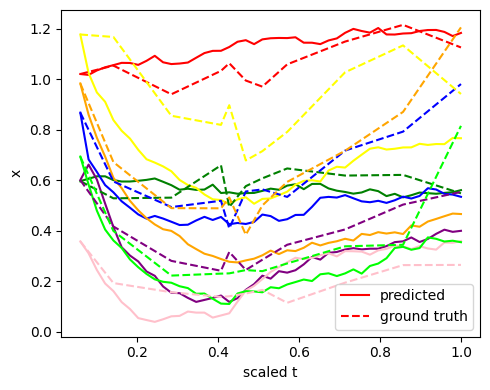

validation loss: 0.03574084863066673
Epoch 2000/10000, Loss: 0.11171942949295044


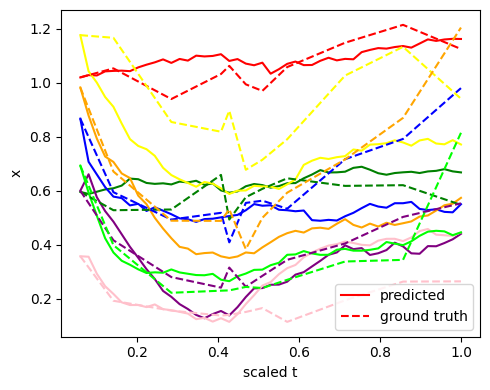

validation loss: 0.025564229115843773
Epoch 2500/10000, Loss: 0.10990880616009235


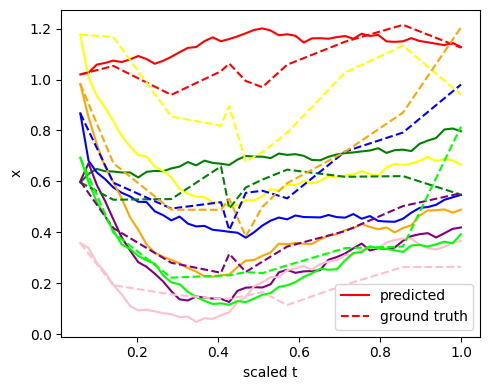

validation loss: 0.04012075439095497
Epoch 3000/10000, Loss: 0.11169581487774849


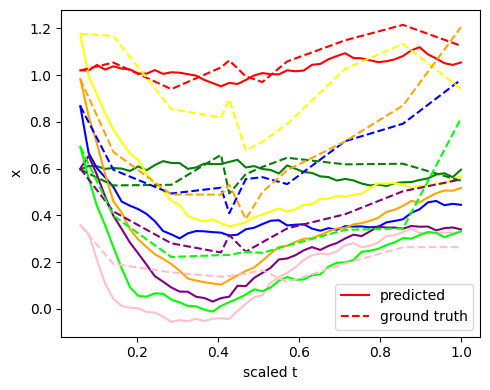

validation loss: 0.06450405716896057
Epoch 3500/10000, Loss: 0.10975711047649384


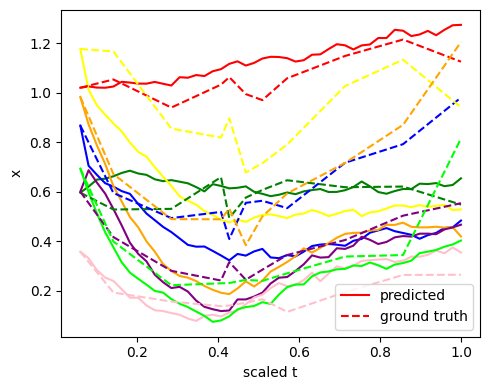

validation loss: 0.04665999487042427
Epoch 4000/10000, Loss: 0.11060096323490143


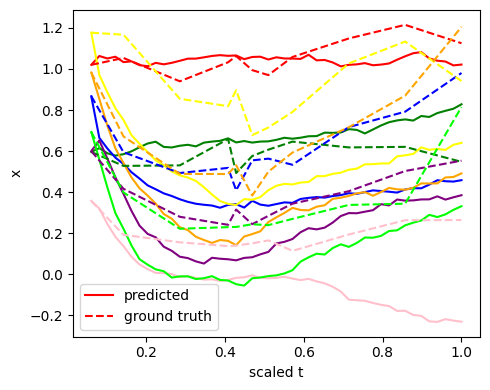

validation loss: 0.07168595492839813
Epoch 4500/10000, Loss: 0.10903299227356911


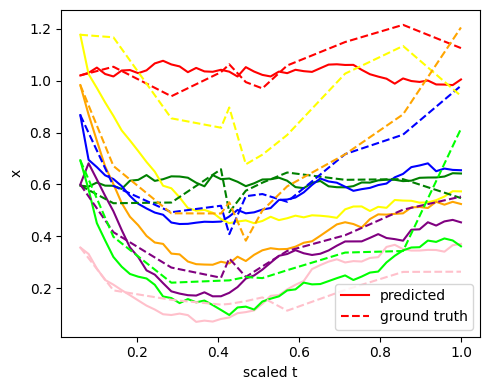

validation loss: 0.03844757750630379
Epoch 5000/10000, Loss: 0.11122698523104191


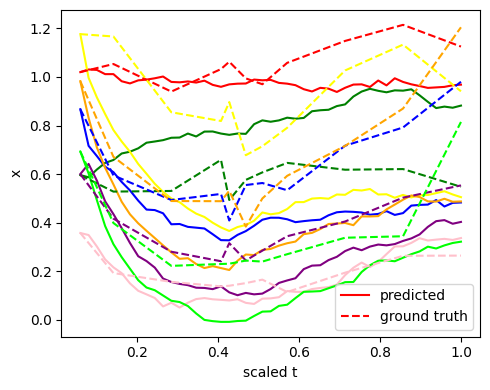

validation loss: 0.06198080629110336
Epoch 5500/10000, Loss: 0.11124066449701786


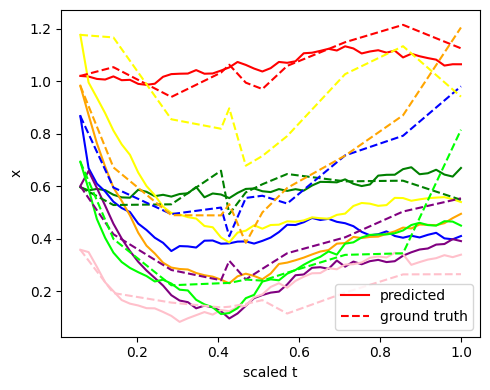

validation loss: 0.04926637187600136
Epoch 6000/10000, Loss: 0.10965062864124775


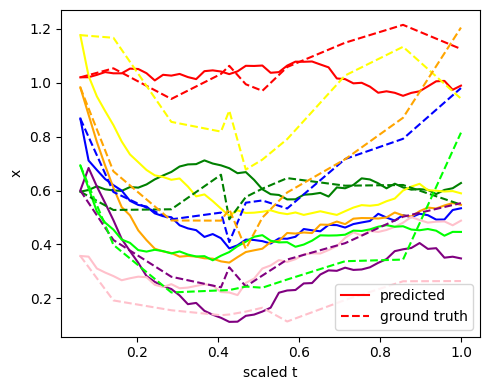

validation loss: 0.041299764066934586
Epoch 6500/10000, Loss: 0.10946469940245152


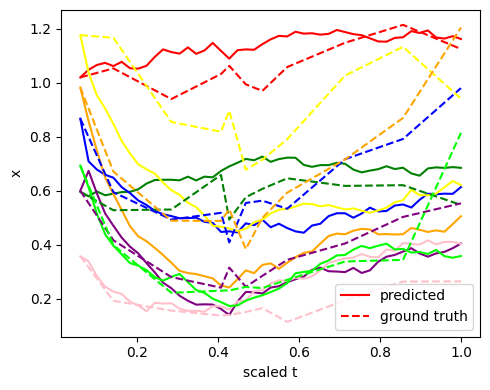

validation loss: 0.040527477860450745
Epoch 7000/10000, Loss: 0.10930122435092926


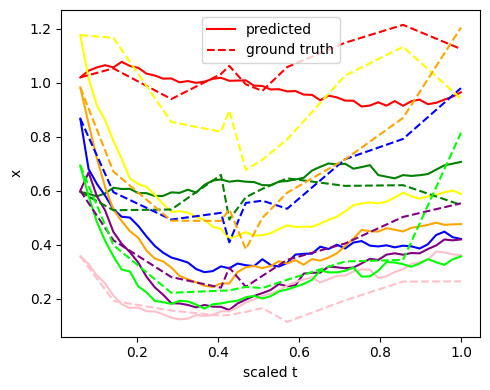

validation loss: 0.05130036547780037
Epoch 7500/10000, Loss: 0.10874318890273571


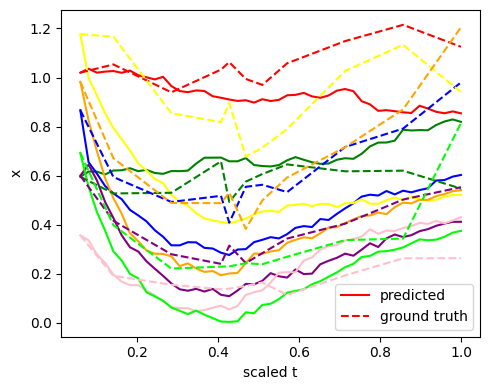

validation loss: 0.05674915760755539
Epoch 8000/10000, Loss: 0.10952660627663136


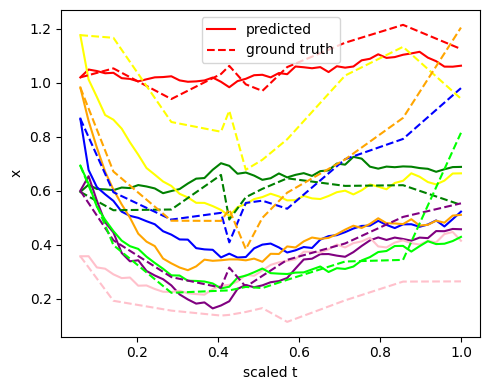

validation loss: 0.03724159300327301
Epoch 8500/10000, Loss: 0.10995884612202644


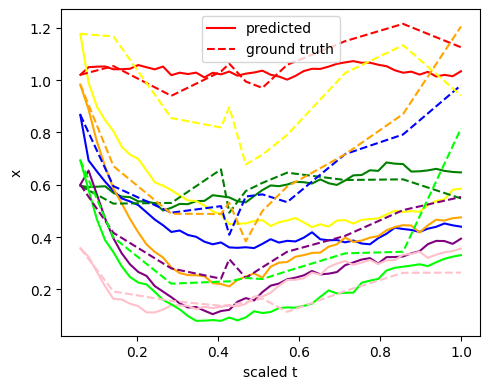

validation loss: 0.05353335663676262
Epoch 9000/10000, Loss: 0.10987677052617073


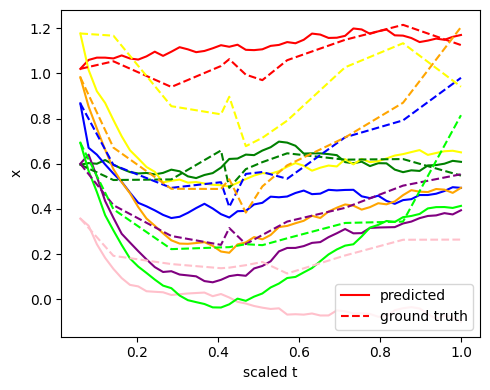

validation loss: 0.05006684362888336
Epoch 9500/10000, Loss: 0.10946607030928135


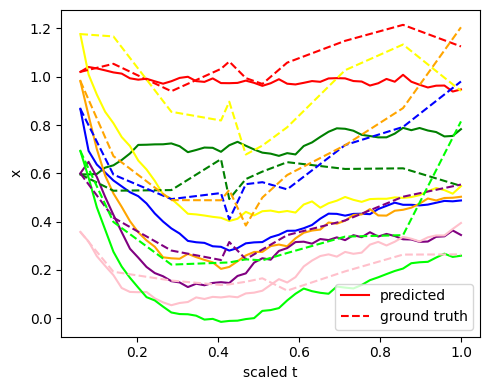

validation loss: 0.06008421257138252
Epoch 10000/10000, Loss: 0.10943214409053326


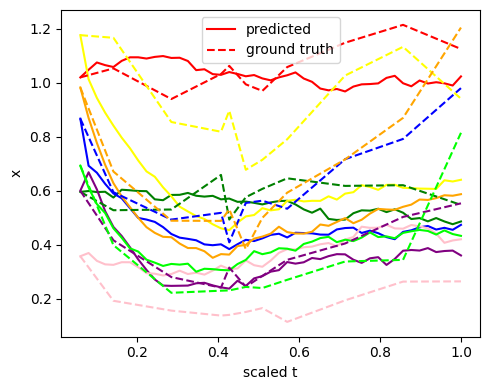

validation loss: 0.03978622704744339

CPU times: user 6min 37s, sys: 721 ms, total: 6min 38s
Wall time: 6min 38s


In [4]:
%%time
# Create the model instance
model = MLP_Cond_Memory_Module(treatment_cond=3, memory=3, 
                                     dim=1, w=6,
                                     time_varying=False, 
                                     conditional=True,
                                     lr=5e-3, 
                                     sigma=2.,
                                     loss_fn=mse_loss, 
                                     metrics=['mse_loss'], 
                                     implementation="SDE", 
                                     sde_noise=0.01, 
                                     clip=0.01).to(device)
# model = MLP_Cond_Memory_Module(treatment_cond=3, memory=0, 
#                                      dim=1, w=12,
#                                      time_varying=False, 
#                                      conditional=True,
#                                      lr=5e-3, 
#                                      sigma=2.,
#                                      loss_fn=mse_loss, 
#                                      metrics=['mse_loss'], 
#                                      implementation="SDE", 
#                                      sde_noise=0.01, 
#                                      clip=0.01).to(device)
# Load the model
try:
    model.load_state_dict(torch.load(model_save_path, weights_only=True))
    test_model(model, False, val_loader_1d_3m, device)
# Train the model
except:
    train_model(model, False, train_loader_1d_3m, val_loader_1d_3m, num_epochs=10000, device=device, 
            eval_every=500, model_save_path = model_save_path)
    if model_save_path is not None:
        model.load_state_dict(torch.load(model_save_path, weights_only=True))
model.eval()  # Set the model to evaluation mode
print()

# Tasks to solve
Your task is to develop a quantum-enhanced model to answer the following questions:

- What is the daily dose level (in whole multiples of 0.5 mg) that ensures that 90% of all subjects in a population similar to the one studied in the phase 1 trial achieve suppression of the biomarker below a clinically relevant threshold (3.3 ng/mL) throughout a 24-hour dosing interval at steady-state?
- Which weekly dose level (in whole multiples of 5 mg) has the same effect over a 168-hour dosing interval at steady-state, if the compound was dosed once-weekly?
- Suppose we change the body weight distribution of the population to be treated to 70-140 kg, how does that affect the optimal once-daily and once-weekly doses?
- Suppose we impose the restriction that concomitant medication is not allowed. How does that affect the optimal once-daily and once-weekly doses?
- How much lower would the optimal doses in the above scenarios be if we were to ensure that only 75% of all subjects achieve suppression of the biomarker below the clinically relevant threshold (3.3 ng/mL)

In [5]:
from torch.distributions.normal import Normal
from torch.distributions.uniform import Uniform
from torch.distributions.bernoulli import Bernoulli

sde = SDE(model.model, noise=0.1)
# Determine the distribution of the biomarker
data_df = pd.read_csv(data_path)
dv_list = []
bw_list = []
for id in range(0, 12):
    data_single = data_df[data_df["ID"] == (id+1)]
    dv_list.append(list(data_single["DV"]))
    bw_list.append([data_single["BW"].iloc[0]] * len(list(data_single["DV"])))
dv_tensor = torch.tensor(dv_list)
dv_disp = Normal(dv_tensor.mean(), dv_tensor.std())
bw_disp = Uniform(50, 100)
bw_disp_shift = Uniform(70, 140)
cm_disp = Bernoulli(0.5)

In [6]:
# The clinically relevant threshold
THRESHOLD = 3.3 / DV_rescale
# Number of steps
len_path = 50
# Number of simulations
sample_shape=(100, 1)
# Dose intervals
doses_daily = torch.arange(0.5, 15., 0.5) / DOSE_rescale
doses_weekly = torch.arange(5., 150., 5.) / DOSE_rescale
# sample initial condition
dv_init = torch.clip(dv_disp.sample(sample_shape=sample_shape) / DV_rescale, min=THRESHOLD)
dv_init = dv_init.repeat(1, 4)
dv_init += torch.randn_like(dv_init) * 0.05
# sample BW
bw = (torch.round(bw_disp.sample(sample_shape=sample_shape)) / BW_rescale).unsqueeze(1).repeat(1, len_path, 1)
bw_shift = (torch.round(bw_disp_shift.sample(sample_shape=sample_shape)) / BW_rescale).unsqueeze(1).repeat(1, len_path, 1)
# Sample COMED
cm = cm_disp.sample(sample_shape=sample_shape).unsqueeze(1).repeat(1, len_path, 1)
cm_false = torch.zeros_like(cm)

#### Q:What is the daily dose level (in whole multiples of 0.5 mg) that ensures that 90% of all subjects in a population similar to the one studied in the phase 1 trial achieve suppression of the biomarker below a clinically relevant threshold (3.3 ng/mL) throughout a 24-hour dosing interval at steady-state?

In [7]:
pred_list = []
dose = doses_daily[5]
for _ in range(10):
    idx = torch.randint(low=0, high=100, size=(1, ))[0]
    x0_classes = torch.cat([dose.unsqueeze(0).repeat(len_path, 1), 
                            bw[idx], cm[idx]], dim=1).to(device)
    x0_values = dv_init[idx, :model.dim].unsqueeze(0).to(device)

    total_pred = []
    total_pred.append(x0_values[0].unsqueeze(0))

    if model.memory > 0:
        time_history = dv_init[idx,-(model.memory * model.dim):].to(device)

    for i in range(len_path):
        time_span = torch.linspace(0., 1./len_path, 10).to(x0_values.device)
        if model.memory > 0:
            new_x_classes = torch.cat([x0_classes[i].unsqueeze(0), time_history.unsqueeze(0)], dim=1)
        else:
            new_x_classes = x0_classes[i].unsqueeze(0)

        with torch.no_grad():
            if i == 0:
                testpt = torch.cat([x0_values[i].unsqueeze(0), new_x_classes], dim=1)
            else:
                testpt = torch.cat([pred_traj, new_x_classes], dim=1)
        traj, noise_traj = sde_solver(sde, testpt, time_span)

        pred_traj = traj[-1, :, :model.dim]
        noise_traj = noise_traj[-1, :, :model.dim]
        if model.memory > 0:
                    flattened_coords = pred_traj.flatten()
                    time_history = torch.cat([time_history[model.dim:].unsqueeze(0), flattened_coords.unsqueeze(0)], dim=1).squeeze()
        total_pred.append(pred_traj)
    total_pred = torch.stack(total_pred).squeeze().detach().cpu().numpy()
    pred_list.append(total_pred)

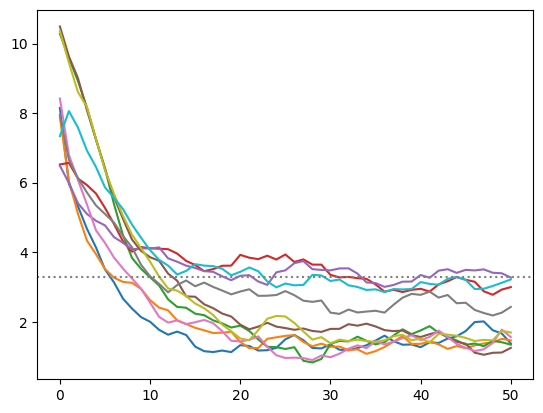

In [8]:
plt.plot(np.array(pred_list).T * DV_rescale)
plt.axhline(y=THRESHOLD * DV_rescale, ls=':', c='gray')

#### Q:Which weekly dose level (in whole multiples of 5 mg) has the same effect over a 168-hour dosing interval at steady-state, if the compound was dosed once-weekly?

In [9]:
pred_list = []
dose = doses_weekly[10]
for _ in range(10):
    idx = torch.randint(low=0, high=100, size=(1, ))[0]
    dose_period = torch.zeros((len_path, 1))
    for i in range(0, len_path, 7):
        dose_period[i] = dose.unsqueeze(0)
    x0_classes = torch.cat([dose_period, 
                            bw[idx], cm[idx]], dim=1).to(device)
    x0_values = dv_init[idx, :model.dim].unsqueeze(0).to(device)

    total_pred = []
    total_pred.append(x0_values[0].unsqueeze(0))

    if model.memory > 0:
        time_history = dv_init[idx,-(model.memory * model.dim):].to(device)

    for i in range(len_path):
        time_span = torch.linspace(0., 1./len_path, 10).to(x0_values.device)
        if model.memory > 0:
            new_x_classes = torch.cat([x0_classes[i].unsqueeze(0), time_history.unsqueeze(0)], dim=1)
        else:
            new_x_classes = x0_classes[i].unsqueeze(0)

        with torch.no_grad():
            if i == 0:
                testpt = torch.cat([x0_values[i].unsqueeze(0), new_x_classes], dim=1)
            else:
                testpt = torch.cat([pred_traj, new_x_classes], dim=1)
        traj, noise_traj = sde_solver(sde, testpt, time_span)

        pred_traj = traj[-1, :, :model.dim]
        noise_traj = noise_traj[-1, :, :model.dim]
        if model.memory > 0:
                    flattened_coords = pred_traj.flatten()
                    time_history = torch.cat([time_history[model.dim:].unsqueeze(0), flattened_coords.unsqueeze(0)], dim=1).squeeze()
        total_pred.append(pred_traj)
    total_pred = torch.stack(total_pred).squeeze().detach().cpu().numpy()
    pred_list.append(total_pred)

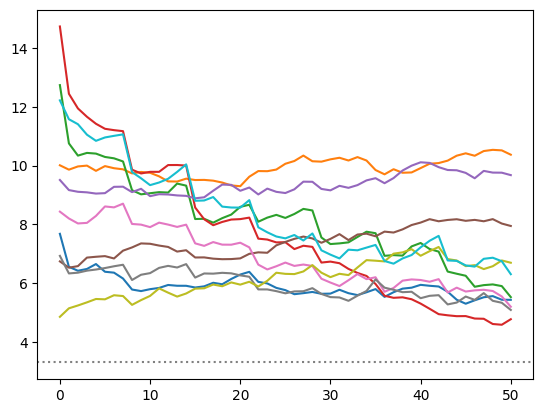

In [10]:
plt.plot(np.array(pred_list).T * DV_rescale)
plt.axhline(y=THRESHOLD * DV_rescale, ls=':', c='gray')

#### Q:Suppose we change the body weight distribution of the population to be treated to 70-140 kg, how does that affect the optimal once-daily and once-weekly doses?

In [11]:
pred_list = []
dose = doses_daily[5]
for _ in range(10):
    idx = torch.randint(low=0, high=100, size=(1, ))[0]
    x0_classes = torch.cat([dose.unsqueeze(0).repeat(len_path, 1), 
                            bw_shift[idx], cm[idx]], dim=1).to(device)
    x0_values = dv_init[idx, :model.dim].unsqueeze(0).to(device)

    total_pred = []
    total_pred.append(x0_values[0].unsqueeze(0))

    if model.memory > 0:
        time_history = dv_init[idx,-(model.memory * model.dim):].to(device)

    for i in range(len_path):
        time_span = torch.linspace(0., 1./len_path, 10).to(x0_values.device)
        if model.memory > 0:
            new_x_classes = torch.cat([x0_classes[i].unsqueeze(0), time_history.unsqueeze(0)], dim=1)
        else:
            new_x_classes = x0_classes[i].unsqueeze(0)

        with torch.no_grad():
            if i == 0:
                testpt = torch.cat([x0_values[i].unsqueeze(0), new_x_classes], dim=1)
            else:
                testpt = torch.cat([pred_traj, new_x_classes], dim=1)
        traj, noise_traj = sde_solver(sde, testpt, time_span)

        pred_traj = traj[-1, :, :model.dim]
        noise_traj = noise_traj[-1, :, :model.dim]
        if model.memory > 0:
                    flattened_coords = pred_traj.flatten()
                    time_history = torch.cat([time_history[model.dim:].unsqueeze(0), flattened_coords.unsqueeze(0)], dim=1).squeeze()
        total_pred.append(pred_traj)
    total_pred = torch.stack(total_pred).squeeze().detach().cpu().numpy()
    pred_list.append(total_pred)

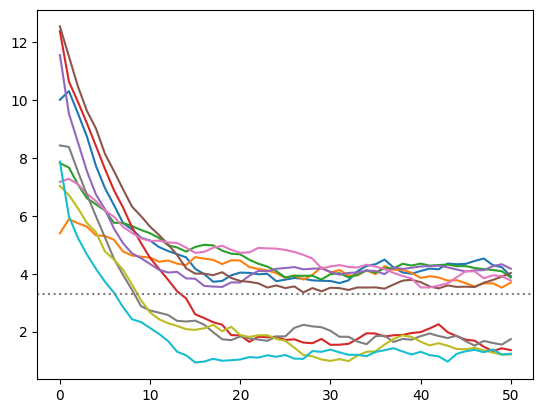

In [12]:
plt.plot(np.array(pred_list).T * DV_rescale)
plt.axhline(y=THRESHOLD * DV_rescale, ls=':', c='gray')

#### Q:Suppose we impose the restriction that concomitant medication is not allowed. How does that affect the optimal once-daily and once-weekly doses?

In [13]:
pred_list = []
dose = doses_daily[5]
for _ in range(10):
    idx = torch.randint(low=0, high=100, size=(1, ))[0]
    x0_classes = torch.cat([dose.unsqueeze(0).repeat(len_path, 1), 
                            bw[idx], cm_false[idx]], dim=1).to(device)
    x0_values = dv_init[idx, :model.dim].unsqueeze(0).to(device)

    total_pred = []
    total_pred.append(x0_values[0].unsqueeze(0))

    if model.memory > 0:
        time_history = dv_init[idx,-(model.memory * model.dim):].to(device)

    for i in range(len_path):
        time_span = torch.linspace(0., 1./len_path, 10).to(x0_values.device)
        if model.memory > 0:
            new_x_classes = torch.cat([x0_classes[i].unsqueeze(0), time_history.unsqueeze(0)], dim=1)
        else:
            new_x_classes = x0_classes[i].unsqueeze(0)

        with torch.no_grad():
            if i == 0:
                testpt = torch.cat([x0_values[i].unsqueeze(0), new_x_classes], dim=1)
            else:
                testpt = torch.cat([pred_traj, new_x_classes], dim=1)
        traj, noise_traj = sde_solver(sde, testpt, time_span)

        pred_traj = traj[-1, :, :model.dim]
        noise_traj = noise_traj[-1, :, :model.dim]
        if model.memory > 0:
                    flattened_coords = pred_traj.flatten()
                    time_history = torch.cat([time_history[model.dim:].unsqueeze(0), flattened_coords.unsqueeze(0)], dim=1).squeeze()
        total_pred.append(pred_traj)
    total_pred = torch.stack(total_pred).squeeze().detach().cpu().numpy()
    pred_list.append(total_pred)

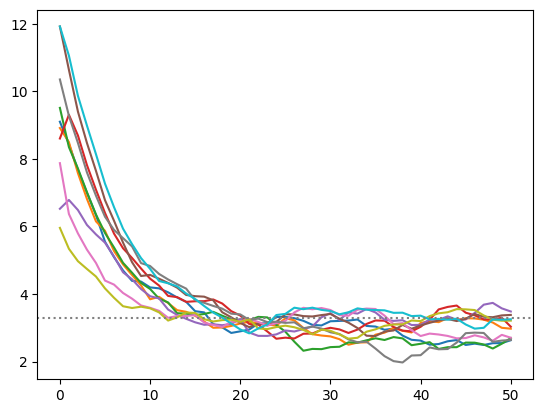

In [14]:
plt.plot(np.array(pred_list).T * DV_rescale)
plt.axhline(y=THRESHOLD * DV_rescale, ls=':', c='gray')

#### Q:How much lower would the optimal doses in the above scenarios be if we were to ensure that only 75% of all subjects achieve suppression of the biomarker below the clinically relevant threshold (3.3 ng/mL)